# Sky background error estimates

> Estimation of the surface brightness limit, including systematic errors due to large-scale spatial variations in the sky background.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial import Polynomial
from photutils.aperture import ApertureStats, CircularAperture
from sigfig import round

## Toy model

Let's create a toy background image.

In [ ]:
npix = 2000
bkg = np.zeros((npix, npix))

Add a flat component.

In [ ]:
flat_bkg = 10
bkg += flat_bkg

Add a spatially varying component, with zero mean on large scales.

In [ ]:
systematic_scale = 1
i, j = np.indices((npix, npix)) / npix
varying_bkg = systematic_scale * np.cos(i * np.pi * 2) * np.sin(j * np.pi * 2)
bkg += varying_bkg

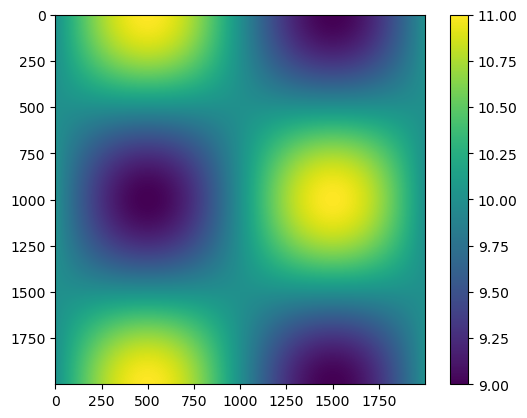

In [ ]:
plt.imshow(bkg, interpolation="none")
plt.colorbar();

Now create a background noise map, assuming the error is Gaussian shot noise. (There is no need for the noise map to be based on the background level map, but it is here.)

In [ ]:
bkg_noise = np.sqrt(bkg)

If we were able to perfectly remove the spatially-varying background level, we would just be left with the noise. This has an average level of:

In [ ]:
round(bkg_noise.mean(), 3)

3.16

In such a case, if we were to average over a 100 pixel radius aperture, we would therefore expect an error on the mean of:

In [ ]:
round(bkg_noise.mean() / np.sqrt(np.pi * 100**2), 3)

0.0178

On the other hand, the spatially-varying background means that if we put down an aperture smaller than the spatial scale of those variations we will tend to measure a value a mean in the aperture that is systematically different from the mean. If we put down lots of random apertures, we would expect a standard deviation on the mean of:

In [ ]:
round(np.std(varying_bkg), 3)

0.5

Note that this does _not_ vary with aperture size, until the size of the aperture becomes comparable with the scale of the background variations, at which point the aperture starts to average over the variations.

## Uncorrelated case

For the sake of simplicity, let's create an image with a uniform source flux. Note that all the results below are actually independent of this source. If the source contributes to the error (shot noise), then the noise map will have more structure. However, if that aspect of the noise is well known, then nothing conceptually changes below.

To begin we will examine the simple case. We add in the (spatially-varying) background noise, but not the spatially-varying background level itself. The errors (residuals from the truth) are independent.

In [ ]:
img_true = np.zeros((npix, npix)) + 100
img_indep = img_true + np.random.normal(scale=bkg_noise, size=(npix, npix))

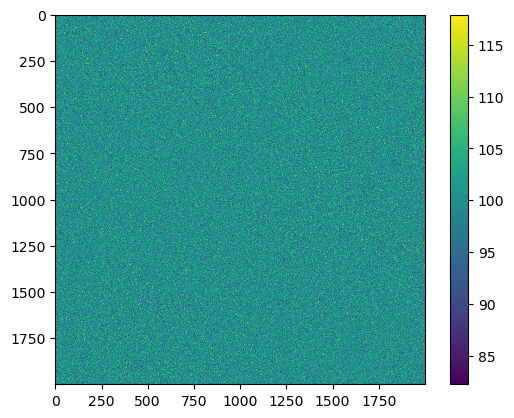

In [ ]:
plt.imshow(img_indep, interpolation="none")
plt.colorbar();

Create a bunch of randomly positioned apertures. I'll use circular apertures, but you could change this to whatever you like.

In [ ]:
radius = 100
n_apertures = 100
centres = np.random.uniform(radius, npix - radius, size=(n_apertures, 2))
apertures = CircularAperture(positions=centres, r=radius)

Now compute the aperture stats on the image.

In [ ]:
img_stats = ApertureStats(img_indep, apertures)

Estimate the total flux in the aperture.

In [ ]:
mean_flux = img_stats.sum
round(mean_flux.mean(), 3)

3140000.0

Estimate the mean flux per pixel.

In [ ]:
mean_flux = img_stats.mean
round(mean_flux.mean(), 3)

100.0

Estimate the uncertainty in the total flux in the aperture.

In [ ]:
var = bkg_noise**2
var_stats = ApertureStats(var, apertures)
err_per_aperture = np.sqrt(var_stats.sum)
round(err_per_aperture.mean(), 3)

558.0

Estimate the uncertainty in the mean flux per pixel.

In [ ]:
err_per_pixel = np.sqrt(var_stats.mean)
round(err_per_pixel.mean(), 3)

3.15

Assuming the pixels are independent, the error on the estimate of the mean flux in each aperture would be the error per pixel divided by the square root of the number of pixels in an aperture.

In [ ]:
n_pixels = var_stats.sum_aper_area.value
err_on_mean_flux = err_per_pixel / np.sqrt(n_pixels)
round(err_on_mean_flux.mean(), 3)

0.0178

Alternatively you could think of it as the error on the total aperture flux, divided by the number of pixels in an aperture.

In [ ]:
err_on_mean_flux = err_per_aperture / n_pixels
round(err_on_mean_flux.mean(), 3)

0.0178

Unsuprisingly, this matches our expectation above. If this is correct, then it should match the scatter on the mean flux measured on lots of apertures. To get an idea of how precise the standard deviation estimated from `n_apertures` apertures is, we also estimate its error.

In [ ]:
stdev_of_mean_flux = np.std(mean_flux)
err_on_stdev_of_mean_flux = stdev_of_mean_flux / np.sqrt(2 * n_apertures - 2)
print(round(stdev_of_mean_flux.mean(), err_on_stdev_of_mean_flux.mean()))

0.016 ± 0.001


So, they agree within the uncertainty.

To put this in more practical terms, let's assume a zeropoint and pixel scale. The mean surface brightness in the aperture is then:

In [ ]:
zp = 30
pixel_scale = 0.1  # arcsec per pixel
sb = -2.5 * np.log10(mean_flux.mean() / pixel_scale**2) + zp
round(sb, 3)

20.0

If the `mean_flux` were to be as low as 3 times the `err_on_mean_flux`, then we would have a signal-to-noise of three, i.e. a marginal detection. We can think of this as our surface brightness limit, which is:

In [ ]:
sb_stat_limit = -2.5 * np.log10(3 * err_on_mean_flux.mean() / pixel_scale**2) + zp
round(sb_stat_limit, 3)

28.2

## Correlated case

Now let's create an image with the same a uniform source flux. Add in the spatially varying background (assuming we are able to perfectly subtract the large-scale flat component) and add noise. Now the errors (residuals from the truth) are correlated.

In [ ]:
img_with_bkg = img_true + varying_bkg
img_corr = img_with_bkg + np.random.normal(scale=bkg_noise, size=(npix, npix))

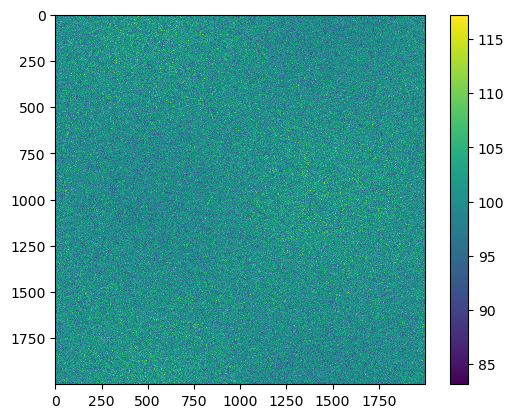

In [ ]:
plt.imshow(img_corr, interpolation="none")
plt.colorbar();

Note that the variation in the background is quite subtle (2 ADU peak to peak, compared with a random noise on each pixel of >3).

Again, we compute the aperture stats, this time on the image with a spatially-varying background.

In [ ]:
img_stats = ApertureStats(img_corr, apertures)

Estimate the total flux in the aperture.

In [ ]:
mean_flux = img_stats.sum
round(mean_flux.mean(), 3)

3140000.0

Estimate the mean flux per pixel.

In [ ]:
mean_flux = img_stats.mean
round(mean_flux.mean(), 3)

99.9

Since the average of the spatially-varying background is zero, these are very close to the values above.

For completeness, we can estimate the uncertainty in the mean flux per pixel, but note that this is exactly the same as above, as we haven't changed `bkg_noise`.

In [ ]:
var = bkg_noise**2
var_stats = ApertureStats(var, apertures)
err_per_pixel = np.sqrt(var_stats.mean)
n_pixels = var_stats.sum_aper_area.value
err_on_mean_flux = err_per_pixel / np.sqrt(n_pixels)
round(err_on_mean_flux.mean(), 3)

0.0178

Now, as an alternative, we can calculate the scatter on the mean flux measured on lots of apertures. In this case we haven't made the assumption of independent pixel errors, but are measuring the uncertainty directly. To get an idea of how precise the standard deviation is, we can also estimate its error.

In [ ]:
stdev_of_mean_flux = np.std(mean_flux)
err_on_stdev_of_mean_flux = stdev_of_mean_flux / np.sqrt(2 * n_apertures - 2)
print(round(stdev_of_mean_flux.mean(), err_on_stdev_of_mean_flux.mean()))

0.56 ± 0.04


Which is substantially (~25 times) larger than the error estimated from the background noise, and very close to that predicted by our initial arguments. This produces a far more meaningful estimate of the limiting surface brightness:

In [ ]:
sb_sys_limit = -2.5 * np.log10(3 * stdev_of_mean_flux.mean() / pixel_scale**2) + zp
round(sb_sys_limit, 3)

24.4

If one were to measure a surface brightness fainter than this in an aperture, there would be a significant chance of it being spurious. It is worth noting again that – unlike `sb_stat_limit`, which continues to get fainter as the aperture grows – `sb_sys_limit` does not improve with aperture size, so long as the apertures are smaller than the scale of the background variations.